In [1]:
import warnings
warnings.filterwarnings('ignore')

# Install Libraries

In [2]:
!pip install -q pandas numpy

In [3]:
!pip install cyvcf2 --quiet
!pip install pysam --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.0/24.0 MB 52.7 MB/s eta 0:00:00


In [4]:
!apt-get update
!apt-get install -y bcftools tabix

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [85.2 kB]
Get:8 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease [24.6 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,797 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,115 kB]
Get:14 htt

# Import All Libraries

In [5]:
import pandas as pd
import numpy as np
import datetime
import os
import subprocess
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import pysam
from cyvcf2 import VCF

# Mount Google Drive for Accessing Data

In [6]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

# Normalizing ClinVar according using the reference fasta file grch38_dna

## Adding chr as prefix to chromosomes names for maintaining data integrity

## Only keep chr 1-22, and removing everything else

In [ ]:
# ====================  FILE PATHS ====================
input_vcf = '/content/drive/MyDrive/FYP_DATA/raw_data/ClinVar/clinvar.vcf.gz'
reference_fasta = '/content/drive/MyDrive/FYP_DATA/raw_data/reference_fasta/hg38_dna.fa'

# Output in processed_data/ClinVar for clarity
output_dir = '/content/drive/MyDrive/FYP_DATA/processed_data/ClinVar'
output_vcf = f'{output_dir}/clinvar_normalized.vcf.gz'

# Temporary files in processed_data/ClinVar for clarity
temp_chr_renamed = f'{output_dir}/temp_chr_renamed.vcf.gz'
temp_filtered = f'{output_dir}/temp_filtered.vcf.gz'
# =========================================================

# Create output directory or check if exists
os.makedirs(output_dir, exist_ok=True)


In [ ]:
# ============================================================
# STEP 2: Add "chr" prefix to chromosome names
# ============================================================
print("\n" + "=" * 70)
print("STEP 2/6: Adding 'chr' prefix to chromosome names...")
print("=" * 70)

# Create chromosome rename file
chr_rename_file = '/tmp/chr_rename.txt'
with open(chr_rename_file, 'w') as f:
    for i in range(1, 23):
        f.write(f"{i} chr{i}\n")
    f.write("X chrX\n")
    f.write("Y chrY\n")
    f.write("MT chrM\n")
    f.write("M chrM\n")

print("📝 Renaming: 1→chr1, 2→chr2, ..., X→chrX, Y→chrY, MT→chrM")

rename_cmd = f"""
bcftools annotate \
    --rename-chrs {chr_rename_file} \
    -O z \
    -o {temp_chr_renamed} \
    {input_vcf}
"""

print("⏱️  Renaming chromosomes ...")
result = subprocess.run(
    rename_cmd,
    shell=True,
    capture_output=True,
    text=True
    )

if result.returncode != 0:
    print("\n CHROMOSOME RENAMING FAILED!")
    print(result.stderr)
    raise Exception("Chromosome renaming failed")

print("✓ Chromosomes renamed")


STEP 2/6: Adding 'chr' prefix to chromosome names...
📝 Renaming: 1→chr1, 2→chr2, ..., X→chrX, Y→chrY, MT→chrM
⏱️  Renaming chromosomes ...
✓ Chromosomes renamed


In [ ]:
# Index with explicit error checking
print("   Creating index for renamed file...")
index_result = subprocess.run(
    f"tabix -f -p vcf {temp_chr_renamed}",
    shell=True,
    capture_output=True,
    text=True
)

if index_result.returncode != 0:
    print(f"   ❌ Indexing failed!")
    print(f"   Error: {index_result.stderr}")
    raise Exception("Failed to create index")
else:
    print(f"   ✓ Index created")

# Verify index exists
if os.path.exists(f"{temp_chr_renamed}.tbi"):
    index_size = os.path.getsize(f"{temp_chr_renamed}.tbi") / 1024
    print(f"Index file verified ({index_size:.1f} KB)")
else:
    print("Index file not found!")
    raise Exception("Failed to create index")

   Creating index for renamed file...
   ✓ Index created
Index file verified (587.9 KB)


In [ ]:
# ============================================================
# STEP 3: Filter to keep only standard chromosomes (1-22)
# ============================================================
print("\n" + "=" * 70)
print("STEP 3/6: Filtering for chromosomes 1-22 only...")
print("=" * 70)

# Create list of chromosomes to keep
chromosomes_to_keep = ','.join([f'chr{i}' for i in range(1, 23)])
# [chr1, chr2, chr3, chr4, ....., chr22]

filter_cmd = f"""
bcftools view \
    -r {chromosomes_to_keep} \
    -O z \
    -o {temp_filtered} \
    {temp_chr_renamed}
"""
result = subprocess.run(
    filter_cmd,
    shell=True,
    capture_output=True,
    text=True
    )

if result.returncode != 0:
    print("\n FILTERING FAILED!")
    print(result.stderr)
    raise Exception("Filtering failed")

print("Filtered to chromosomes 1-22")


STEP 3/6: Filtering for chromosomes 1-22 only...
Filtered to chromosomes 1-22


In [ ]:
# Index filtered file
print("Creating index for filtered file...")
index_result = subprocess.run(
    f"tabix -f -p vcf {temp_filtered}",
    shell=True,
    capture_output=True,
    text=True
)

if index_result.returncode != 0:
    print(f"   Indexing failed!")
    print(f"   Error: {index_result.stderr}")
else:
    print(f"   Index created")

Creating index for filtered file...
   Index created


In [ ]:
# ============================================================
# STEP 4: Normalize VCF
# ============================================================
print("\n" + "=" * 70)
print("STEP 4/6: Normalizing VCF...")
print("=" * 70)

norm_cmd = f"""
bcftools norm \
    -m- \
    -f {reference_fasta} \
    --check-ref w \
    -O z \
    -o {output_vcf} \
    {temp_filtered}
"""

result = subprocess.run(
    norm_cmd,
    shell=True,
    capture_output=True,
    text=True
    )
# normalization stasts
print(result.stderr)

if result.returncode != 0:
    print("\n NORMALIZATION FAILED!")
    print(result.stdout)
    print(result.stderr)
    raise Exception("Normalization failed")

print(f"\n Normalized VCF created successfully!")


STEP 4/6: Normalizing VCF...
Lines   total/split/realigned/skipped:	3942986/0/0/0


 Normalized VCF created successfully!


In [ ]:
# ============================================================
# STEP 5: Index normalized VCF
# ============================================================
print("\n" + "=" * 70)
print("STEP 5/6: Indexing normalized VCF...")
print("=" * 70)

index_cmd = f"tabix -f -p vcf {output_vcf}"

result = subprocess.run(
    index_cmd,
    shell=True,
    capture_output=True,
    text=True
    )

if result.returncode == 0:
    print(f"Index created: {output_vcf}.tbi")
else:
    print("Indexing failed!")
    print(result.stderr)
    raise Exception("Indexing failed")


STEP 5/6: Indexing normalized VCF...
Index created: /content/drive/MyDrive/FYP_DATA/processed_data/ClinVar/clinvar_normalized.vcf.gz.tbi


In [ ]:
 #============================================================
# STEP 6: Verify and cleanup
# ============================================================
print("\n" + "=" * 70)
print("STEP 6/6: Verifying normalization...")
print("=" * 70)

vcf_norm = VCF(output_vcf)

# Check chromosomes present
chromosomes_found = set()
multi_count = 0
total = 0

print("\nScanning variants...")

for variant in vcf_norm:
    chromosomes_found.add(variant.CHROM)
    if len(variant.ALT) > 1:
        multi_count += 1
    total += 1

print(f"\n Verification Results:")
print(f"   Total variants checked: {total:,}")
print(f"   Chromosomes found: {sorted(chromosomes_found)}")
print(f"   Multi-allelic variants: {multi_count}")

if multi_count == 0:
    print("   ✓ All variants are properly split!")
else:
    print(f"   ⚠️  Found {multi_count} multi-allelic variants")


STEP 6/6: Verifying normalization...

Scanning variants...

 Verification Results:
   Total variants checked: 3,942,986
   Chromosomes found: ['chr1', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr2', 'chr20', 'chr21', 'chr22', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9']
   Multi-allelic variants: 0
   ✓ All variants are properly split!


In [ ]:
# Cleanup temporary files
print("\n Cleaning up temporary files...")
temp_files = [
    temp_chr_renamed,
    temp_chr_renamed + '.tbi',
    temp_filtered,
    temp_filtered + '.tbi'
]

cleaned_count = 0
for temp_file in temp_files:
    if os.path.exists(temp_file):
        try:
            os.remove(temp_file)
            cleaned_count += 1
            print(f"   Removed: {os.path.basename(temp_file)}")
        except Exception as e:
            print(f"   Could not remove {os.path.basename(temp_file)}: {e}")

print(f"\nCleaned up {cleaned_count} temporary files")


 Cleaning up temporary files...
   Removed: temp_chr_renamed.vcf.gz
   Removed: temp_chr_renamed.vcf.gz.tbi
   Removed: temp_filtered.vcf.gz
   Removed: temp_filtered.vcf.gz.tbi

Cleaned up 4 temporary files


In [ ]:
print("\n" + "=" * 70)
print("✅ STEP 1 COMPLETE: VCF NORMALIZATION SUCCESSFUL!")
print("=" * 70)

print(f"\n📂 Output directory:")
print(f"   {output_dir}")
print(f"\n📂 Normalized VCF file:")
print(f"   {os.path.basename(output_vcf)}")
print(f"\n📂 Index file:")
print(f"   {os.path.basename(output_vcf)}.tbi")
print(f"\n📊 Summary:")
print(f"   • Contains only chromosomes 1-22")
print(f"   • All variants normalized and left-aligned")
print(f"   • Multi-allelic variants split")
print(f"\n📁 All ClinVar processed files are in:")
print(f"   {output_dir}")
print("=" * 70)


✅ STEP 1 COMPLETE: VCF NORMALIZATION SUCCESSFUL!

📂 Output directory:
   /content/drive/MyDrive/FYP_DATA/processed_data/ClinVar

📂 Normalized VCF file:
   clinvar_normalized.vcf.gz

📂 Index file:
   clinvar_normalized.vcf.gz.tbi

📊 Summary:
   • Contains only chromosomes 1-22
   • All variants normalized and left-aligned
   • Multi-allelic variants split

📁 All ClinVar processed files are in:
   /content/drive/MyDrive/FYP_DATA/processed_data/ClinVar


In [ ]:
# File paths
normalized_vcf = '/content/drive/MyDrive/FYP_DATA/processed_data/ClinVar/clinvar_normalized.vcf.gz'

print("=" * 70)
print("STEP 2: EXTRACT VCF TO DATAFRAME")
print("=" * 70)
print(f"\n📥 Input:  {normalized_vcf}")

STEP 2: EXTRACT VCF TO DATAFRAME

📥 Input:  /content/drive/MyDrive/FYP_DATA/processed_data/ClinVar/clinvar_normalized.vcf.gz


In [ ]:
def extract_vcf_to_dataframe(vcf_path):

    variants = []
    count = 0
    print("\nExtracting data from VCF...")


    vcf = VCF(vcf_path)

    for variant in vcf:
        # Basic variant info
        chrom = variant.CHROM
        pos = variant.POS
        ref = variant.REF
        alt = variant.ALT[0] if variant.ALT else None

        # Extract INFO fields
        clnsig = variant.INFO.get('CLNSIG', None)
        mc = variant.INFO.get('MC', None)
        geneinfo = variant.INFO.get('GENEINFO', None)
        clnrevstat = variant.INFO.get('CLNREVSTAT', None)
        clndn = variant.INFO.get('CLNDN', None)

        # Store in list
        variants.append({
            'CHROM': chrom,
            'POS': pos,
            'REF': ref,
            'ALT': alt,
            'CLNSIG': clnsig,
            'MC': mc,
            'GENEINFO': geneinfo,
            'CLNREVSTAT': clnrevstat,
            'CLNDN': clndn
        })

        count += 1
        if count % 10000 == 0:
            print(f"   {count:,} variants extracted")

    # Convert to DataFrame
    df = pd.DataFrame(variants)
    print(f"Parsed {len(df):,} variants")

    return df

In [ ]:
clinvar_df = extract_vcf_to_dataframe(normalized_vcf)


Extracting data from VCF...
   10,000 variants extracted
   20,000 variants extracted
   30,000 variants extracted
   40,000 variants extracted
   50,000 variants extracted
   60,000 variants extracted
   70,000 variants extracted
   80,000 variants extracted
   90,000 variants extracted
   100,000 variants extracted
   110,000 variants extracted
   120,000 variants extracted
   130,000 variants extracted
   140,000 variants extracted
   150,000 variants extracted
   160,000 variants extracted
   170,000 variants extracted
   180,000 variants extracted
   190,000 variants extracted
   200,000 variants extracted
   210,000 variants extracted
   220,000 variants extracted
   230,000 variants extracted
   240,000 variants extracted
   250,000 variants extracted
   260,000 variants extracted
   270,000 variants extracted
   280,000 variants extracted
   290,000 variants extracted
   300,000 variants extracted
   310,000 variants extracted
   320,000 variants extracted
   330,000 variants 

📦 Pickle vs CSV - Why Pickle is Better Here:
CSV Issues:

❌ Loses data types (everything becomes string)
❌ Larger file size (text format)
❌ Slower to read/write
❌ Can have issues with special characters
❌ Need to re-parse on load

Pickle Advantages:

✅ Preserves exact data types
✅ Smaller file size (binary format)
✅ Much faster to read/write
✅ No parsing needed
✅ Perfect for intermediate processing steps

In [ ]:
# we will save as pickle to load again, but for optional backup we will also store it as a csv

In [ ]:
output_pickle = '/content/drive/MyDrive/FYP_DATA/processed_data/ClinVar/clinvar_v1_raw_extracted.pkl'
output_csv = '/content/drive/MyDrive/FYP_DATA/processed_data/ClinVar/clinvar_v1_raw_extracted.csv'
print("=" * 70)
print("STEP 2: EXTRACT VCF TO DATAFRAME")
print("=" * 70)
print(f"\n📥 Input:  {normalized_vcf}")
print(f"📤 Output: {output_pickle}")
print(f"📤 Output: {output_csv}")

print("💡 Version: v1_raw_extracted as pickle (post-normalization, pre-filtering)")
print("💡 Version: v1_raw_extracted as csv (post-normalization, pre-filtering)")


STEP 2: EXTRACT VCF TO DATAFRAME

📥 Input:  /content/drive/MyDrive/FYP_DATA/processed_data/ClinVar/clinvar_normalized.vcf.gz
📤 Output: /content/drive/MyDrive/FYP_DATA/processed_data/ClinVar/clinvar_v1_raw_extracted.pkl
📤 Output: /content/drive/MyDrive/FYP_DATA/processed_data/ClinVar/clinvar_v1_raw_extracted.csv
💡 Version: v1_raw_extracted as pickle (post-normalization, pre-filtering)
💡 Version: v1_raw_extracted as csv (post-normalization, pre-filtering)


In [ ]:
def save_clinvar_pickle(df, output_pickle):

  print("\n" + "=" * 70)
  print("SAVING DATA")
  print("=" * 70)

  print(f"\n💾 Saving to pickle...")
  with open(output_pickle, 'wb') as f:
    pickle.dump(clinvar_df, f, protocol=pickle.HIGHEST_PROTOCOL)

  pickle_size_mb = os.path.getsize(output_pickle) / (1024**2)
  print(f"✓ Saved: {os.path.basename(output_pickle)}")
  print(f"  Size: {pickle_size_mb:.2f} MB")

In [ ]:
def save_clinvar_csv(df, output_csv):
  print("\n" + "=" * 70)
  print("SAVING DATA")
  print("=" * 70)

  print(f"\n💾 Saving to csv...")
  df.to_csv(output_csv, index=False)

  csv_size_mb = os.path.getsize(output_csv) / (1024**2)
  print(f"✓ Saved: {os.path.basename(output_csv)}")
  print(f"  Size: {csv_size_mb:.2f} MB")



In [ ]:
save_clinvar_pickle(clinvar_df,output_pickle)
save_clinvar_csv(clinvar_df, output_csv)


SAVING DATA

💾 Saving to pickle...
✓ Saved: clinvar_v1_raw_extracted.pkl
  Size: 656.73 MB

SAVING DATA

💾 Saving to csv...
✓ Saved: clinvar_v1_raw_extracted.csv
  Size: 609.68 MB


In [ ]:
clinvar_df.head()

,CHROM,POS,REF,ALT,CLNSIG,MC,GENEINFO,CLNREVSTAT,CLNDN
0,chr1,66926,AG,A,Uncertain_significance,SO:0001627|intron_variant,OR4F5:79501,"criteria_provided,_single_submitter",Retinitis_pigmentosa
1,chr1,69134,A,G,Likely_benign,SO:0001583|missense_variant,OR4F5:79501,"criteria_provided,_single_submitter",not_specified
2,chr1,69308,A,G,Uncertain_significance,SO:0001583|missense_variant,OR4F5:79501,"criteria_provided,_single_submitter",not_specified
3,chr1,69314,T,G,Uncertain_significance,SO:0001583|missense_variant,OR4F5:79501,"criteria_provided,_single_submitter",not_specified
4,chr1,69404,T,C,Uncertain_significance,SO:0001583|missense_variant,OR4F5:79501,"criteria_provided,_single_submitter",not_specified


# Visualizing Data

In [ ]:
def class_distributions(df):
  # Create a copy for plotting so we don't modify the original dataframe
  plot_df = df.copy()

  def simplify_label_for_plot(label):
    s = str(label).lower()
    if 'conflicting' in s: return 'Conflicting'
    if 'uncertain' in s: return 'Uncertain (VUS)'
    if 'likely_benign' in s: return 'Likely Benign'
    if 'benign' in s: return 'Benign'
    if 'likely_pathogenic' in s: return 'Likely Pathogenic'
    if 'pathogenic' in s: return 'Pathogenic'
    return 'Other'

  plot_df['plot_label'] = plot_df['CLNSIG'].apply(simplify_label_for_plot)

  plt.figure(figsize=(10, 6))
  sns.set_style("whitegrid")
  order = plot_df['plot_label'].value_counts().index
  ax = sns.countplot(y='plot_label', data=plot_df, order=order, palette='viridis')

  # Add titles and labels
  plt.title("Distribution of Clinical Significance in ClinVar", fontsize=14, pad=20)
  plt.xlabel("Number of Variants", fontsize=12)
  plt.ylabel("Clinical Classification", fontsize=12)

  # Add the actual numbers at the end of each bar
  for container in ax.containers:
      ax.bar_label(container, padding=3)

  plt.tight_layout()
  plt.show()

def cons_dist(df):
  plt.figure(figsize=(12,6))
  sns.countplot(y='MC', data=df, order=df['MC'].value_counts().index[:20])
  plt.title("Top 20 Molecular Consequences")
  plt.xlabel("Count")
  plt.ylabel("MC")
  plt.tight_layout()
  plt.show()

def chrom_count(df):
  plot_df = df.copy()

  plot_df = plot_df[plot_df['CHROM'].isin([f'chr{i}' for i in range(1,23)])]

  plt.figure(figsize=(12, 6))
  sns.set_style("whitegrid")

  chrom_counts = plot_df['CHROM'].value_counts()

  sorted_index = sorted(chrom_counts.index, key=lambda x: int(x.replace('chr','')))
  sorted_counts = chrom_counts.reindex(sorted_index)

  ax = sns.barplot(x=sorted_counts.index, y=sorted_counts.values,
                   hue=sorted_counts.index, palette='viridis')

  plt.title("Variant Counts per Autosome (Chr 1-22 Only)", fontsize=14, pad=15)
  plt.xlabel("Chromosome", fontsize=12)
  plt.ylabel("Count", fontsize=12)

  plt.xticks(rotation=0)

  plt.tight_layout()
  plt.show()

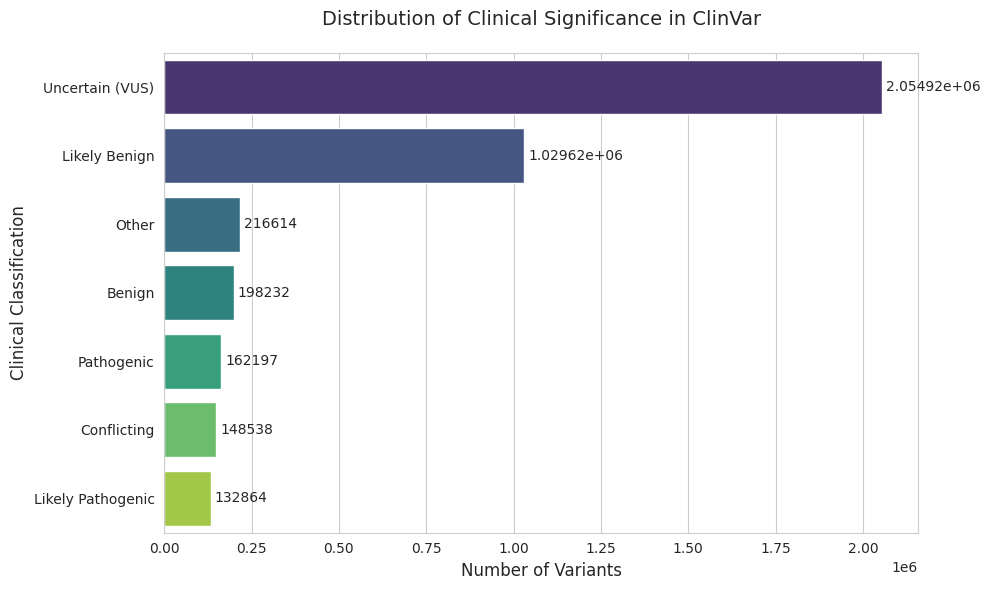

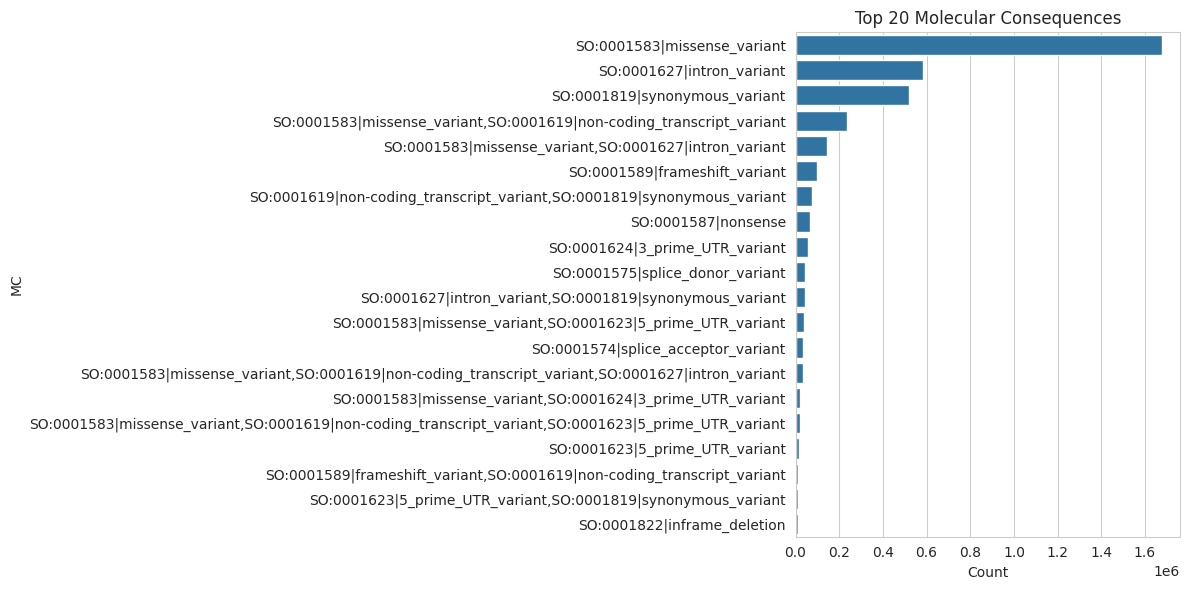

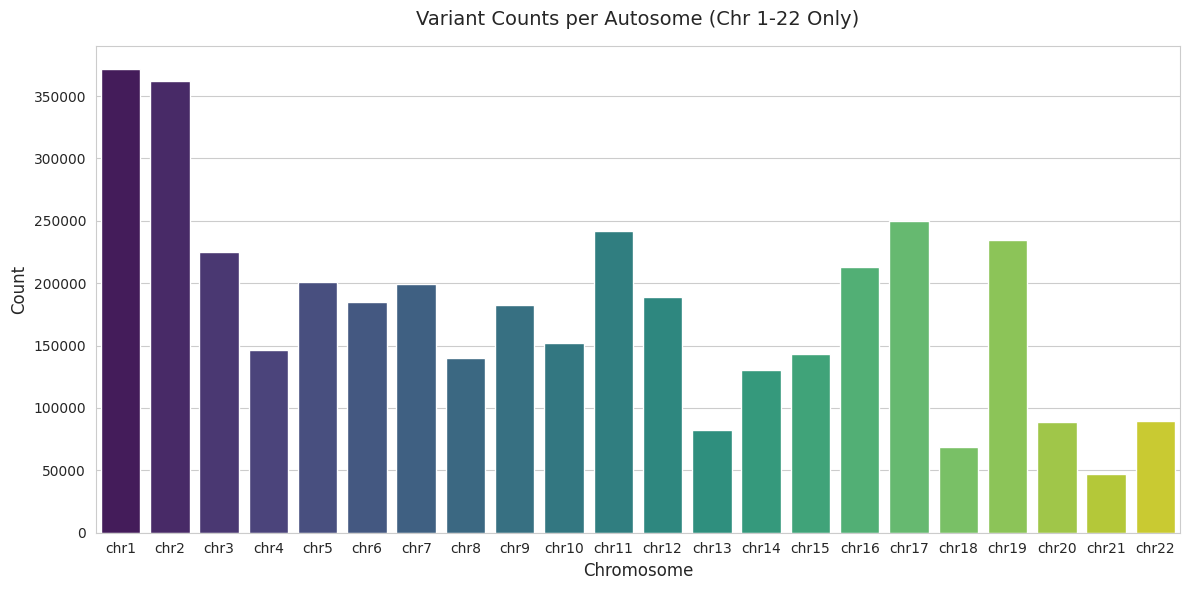

In [ ]:
class_distributions(clinvar_df)
cons_dist(clinvar_df)
chrom_count(clinvar_df)

# Filtering for missense variants

In [ ]:
# v2.0 so loading the df
clinvar_df = pd.read_pickle('/content/drive/MyDrive/FYP_DATA/processed_data/ClinVar/clinvar_v1_raw_extracted.pkl')
clinvar_df.head()

,CHROM,POS,REF,ALT,CLNSIG,MC,GENEINFO,CLNREVSTAT,CLNDN
0,chr1,66926,AG,A,Uncertain_significance,SO:0001627|intron_variant,OR4F5:79501,"criteria_provided,_single_submitter",Retinitis_pigmentosa
1,chr1,69134,A,G,Likely_benign,SO:0001583|missense_variant,OR4F5:79501,"criteria_provided,_single_submitter",not_specified
2,chr1,69308,A,G,Uncertain_significance,SO:0001583|missense_variant,OR4F5:79501,"criteria_provided,_single_submitter",not_specified
3,chr1,69314,T,G,Uncertain_significance,SO:0001583|missense_variant,OR4F5:79501,"criteria_provided,_single_submitter",not_specified
4,chr1,69404,T,C,Uncertain_significance,SO:0001583|missense_variant,OR4F5:79501,"criteria_provided,_single_submitter",not_specified


In [ ]:
len(clinvar_df)

3942986

In [ ]:
# check unique entries in the mc column
clinvar_df['MC'].unique()

array(['SO:0001627|intron_variant', 'SO:0001583|missense_variant',
       'SO:0001619|non-coding_transcript_variant', None,
       'SO:0001819|synonymous_variant', 'SO:0001575|splice_donor_variant',
       'SO:0001822|inframe_deletion', 'SO:0001587|nonsense',
       'SO:0001589|frameshift_variant', 'SO:0001821|inframe_insertion',
       'SO:0001575|splice_donor_variant,SO:0001587|nonsense',
       'SO:0001575|splice_donor_variant,SO:0001821|inframe_insertion',
       'SO:0001583|missense_variant,SO:0001627|intron_variant',
       'SO:0001627|intron_variant,SO:0001819|synonymous_variant',
       'SO:0001589|frameshift_variant,SO:0001627|intron_variant',
       'SO:0001575|splice_donor_variant,SO:0001627|intron_variant',
       'SO:0001574|splice_acceptor_variant',
       'SO:0002073|no_sequence_alteration',
       'SO:0001624|3_prime_UTR_variant',
       'SO:0001574|splice_acceptor_variant,SO:0001627|intron_variant',
       'SO:0001623|5_prime_UTR_variant,SO:0001627|intron_variant',
   

In [ ]:
# we will keep only missense, and wherever it is labelled missense we will keep it
def filter_for_missense(df):
  missense_df = df[df['MC'].str.contains('missense', case=False, na=False)].copy()
  return missense_df
def clean_mc(mc_value):
  if not mc_value:
    return None
  mc_value = str(mc_value)

  if "missense_variant" in mc_value:
    return "missense_variant"
  else:
    return None # drop other non missense variants

In [ ]:
clinvar_df = filter_for_missense(clinvar_df)
clinvar_df['MC'] = clinvar_df['MC'].apply(clean_mc)

In [ ]:
len(clinvar_df)

2214011

In [ ]:
clinvar_df['MC'].nunique()

1

In [ ]:
output_pickle = '/content/drive/MyDrive/FYP_DATA/processed_data/ClinVar/clinvar_v2_missense_filtered.pkl'
save_clinvar_pickle(clinvar_df,output_pickle)


SAVING DATA

💾 Saving to pickle...
✓ Saved: clinvar_v2_missense_filtered.pkl
  Size: 318.62 MB


In [ ]:
def categorize_clinical_label(clnsig):

  if clnsig is None or pd.isna(clnsig):
    return 'Other'

  clnsig_lower = clnsig.lower().strip()

  pathogenic_labels = {
      'pathogenic',
      'pathogenic|risk_factor',
      'pathogenic,_low_penetrance',
      'pathogenic/pathogenic,_low_penetrance',
      'pathogenic|protective',
      'pathogenic|other',
      'pathogenic|association',
      'pathogenic|drug_response',
      'pathogenic|affects',
      'pathogenic/likely_risk_allele',
      'pathogenic|confers_sensitivity',
      'pathogenic/pathogenic,_low_penetrance|other',
      'pathogenic/likely_pathogenic|other',
      'pathogenic/likely_pathogenic',
      'pathogenic/likely_pathogenic/pathogenic,_low_penetrance',
      'pathogenic/likely_pathogenic|risk_factor',
      'pathogenic/likely_pathogenic,_low_penetrance',
      'pathogenic/likely_pathogenic/likely_risk_allele',
      'pathogenic/likely_pathogenic/pathogenic,_low_penetrance|risk_factor',
      'pathogenic/likely_pathogenic|association',
      'likely_pathogenic/pathogenic,_low_penetrance',
  }
  likely_pathogenic_labels = {
      'likely_pathogenic,_low_penetrance',
      'likely_pathogenic/likely_pathogenic,_low_penetrance',
      'likely_pathogenic/likely_risk_allele',
      'likely_pathogenic|drug_response',
      'likely_pathogenic|protective',
      'likely_pathogenic|association',
      'likely_pathogenic|affects',
      'likely_pathogenic|risk_factor',
  }
  conflicting_classifications_of_pathogenicity_labels = {
      'conflicting_classifications_of_pathogenicity|association',
      'conflicting_classifications_of_pathogenicity|other',
      'conflicting_classifications_of_pathogenicity|drug_response|other',
      'conflicting_classifications_of_pathogenicity|drug_response',
      'conflicting_classifications_of_pathogenicity|protective',
      'conflicting_classifications_of_pathogenicity|association|risk_factor',
      'conflicting_classifications_of_pathogenicity|other|risk_factor',
      'conflicting_classifications_of_pathogenicity|affects',
      'conflicting_classifications_of_pathogenicity|risk_factor',
  }
  benign_labels = {
      'benign',
      'benign/likely_benign',
      'benign|other',
      'benign/likely_benign|other',
      'benign|association',
      'benign|drug_response',
      'benign|protective',
      'benign|risk_factor',
      'benign/likely_benign|other|risk_factor',
      'benign/likely_benign|association',
      'benign|affects|association|other',
      'benign/likely_benign|risk_factor',
      'benign|affects',
      'benign/likely_benign|drug_response',
      'benign/likely_benign|drug_response|other',
      'benign|confers_sensitivity',
  }
  likely_benign_labels = {
      'likely_benign',
      'likely_benign|association',
      'likely_benign|affects|association',
      'likely_benign|other',
      'likely_benign|drug_response',
      'likely_benign|drug_response|other',
      'likely_benign|risk_factor',
  }
  vus_labels = {
      'uncertain_significance',
      'uncertain_risk_allele',
      'uncertain_significance/uncertain_risk_allele',
      'uncertain_significance|risk_factor',
      'uncertain_significance|association',
      'uncertain_significance|other',
      'uncertain_significance|drug_response',
      'uncertain_significance|affects',
      'uncertain_risk_allele|risk_factor',
  }

  if clnsig_lower in pathogenic_labels:
    return 'Pathogenic'
  elif clnsig_lower in likely_pathogenic_labels:
    return 'Likely_Pathogenic'
  elif clnsig_lower in benign_labels:
    return 'Benign'
  elif clnsig_lower in likely_benign_labels:
    return 'Likely_Benign'
  elif clnsig_lower in conflicting_classifications_of_pathogenicity_labels:
    return 'Conflicting_Classifications_of_Pathogenicity'
  elif clnsig_lower in vus_labels:
    return 'VUS'
  else:
    return 'Other'

In [ ]:
# applying it to our df
clinvar_df['CLNSIG_CATEGORY'] = clinvar_df['CLNSIG'].apply(categorize_clinical_label)

In [ ]:
clinvar_df['CLNSIG_CATEGORY'].unique()

array(['Likely_Benign', 'VUS', 'Benign', 'Other', 'Pathogenic',
       'Conflicting_Classifications_of_Pathogenicity',
       'Likely_Pathogenic'], dtype=object)

In [ ]:
def visual_cat(df):
  plt.figure(figsize=(10,6))
  sns.set_style("whitegrid")

  order = df['CLNSIG_CATEGORY'].value_counts().index
  ax = sns.countplot(y='CLNSIG_CATEGORY', data=df, order=order, palette = 'viridis', hue='CLNSIG_CATEGORY', legend=False)

  plt.title("Distribution of Categorized Clinical Labels", fontsize=14, pad=20)
  plt.xlabel("Number of Variants", fontsize=12)
  plt.ylabel("Category", fontsize=12)

  # Add count labels
  for container in ax.containers:
    ax.bar_label(container, padding=3)

  plt.tight_layout()
  plt.show()

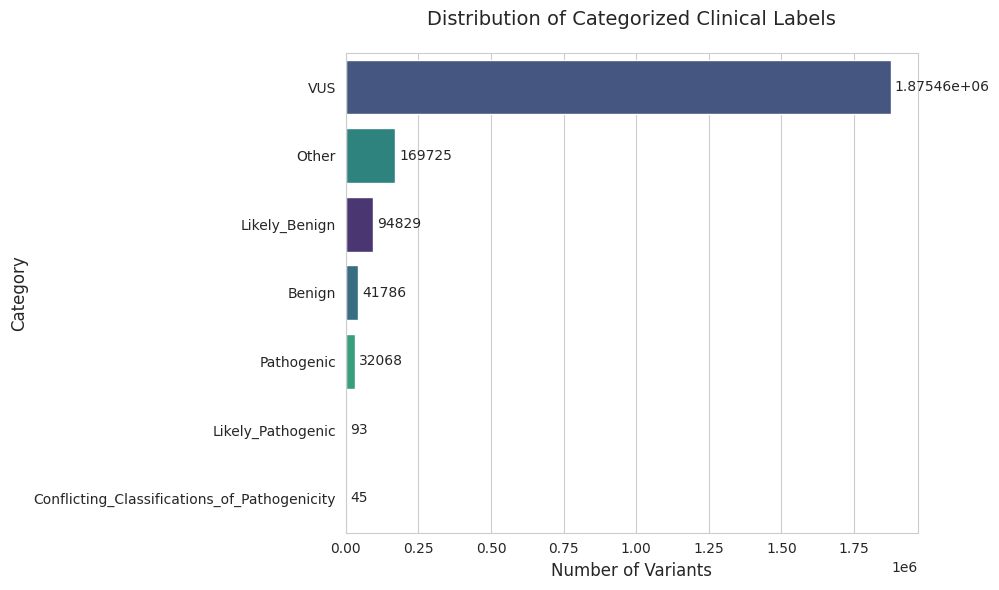

In [ ]:
visual_cat(clinvar_df)

array(['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8',
       'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15',
       'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 'chr21', 'chr22'],
      dtype=object)

In [ ]:
output_pickle = '/content/drive/MyDrive/FYP_DATA/processed_data/ClinVar/clinvar_v3_missense_filtered_and_categorized.pkl'
save_clinvar_pickle(clinvar_df,output_pickle)


SAVING DATA

💾 Saving to pickle...
✓ Saved: clinvar_v3_missense_filtered_and_categorized.pkl
  Size: 329.18 MB


In [ ]:
#donot run this cell again
clinvar_df = pd.read_pickle('/content/drive/MyDrive/FYP_DATA/processed_data/ClinVar/clinvar_v3_missense_filtered_and_categorized.pkl')

In [ ]:
clinvar_df.columns

Index(['CHROM', 'POS', 'REF', 'ALT', 'CLNSIG', 'MC', 'GENEINFO', 'CLNREVSTAT',
       'CLNDN', 'CLNSIG_CATEGORY'],
      dtype='object')

In [ ]:
# final lookup dictionary
def get_clinvar_dict(pickle_path):
  print(f"Loading clinvar data from: {os.path.basename(pickle_path)}")

  df = pd.read_pickle(pickle_path)
  print(f"Total rows loaded: {len(df):,}")

  req_cols = ['CHROM','POS','REF','ALT', 'CLNSIG_CATEGORY']
  df_clean = df[req_cols].copy()

  org_len = len(df_clean)
  df_clean = df_clean.dropna()
  dropped = org_len - len(df_clean)
  print(f"Dropped {dropped:,} rows with missing values")

  clinvar_dict = {}
  dups = 0
  confs = 0
  skipped = 0

  for chrom, pos, ref, alt, label in zip(
    df_clean['CHROM'],
    df_clean['POS'],
    df_clean['REF'],
    df_clean['ALT'],
    df_clean['CLNSIG_CATEGORY']):

    try:
      chrom = str(chrom).strip()
      pos = int(pos)
      ref = str(ref).strip().upper()
      alt = str(alt).strip().upper()
      label = str(label).strip()
    except (ValueError, AttributeError):
      skipped +=1
      continue

    if not all([chrom,ref,alt,label]) or pos <=0:
      skipped +=1
      continue

    key = (chrom, pos, ref, alt)
    if key in clinvar_dict:
      dups +=1
      if clinvar_dict[key]!=label:
        confs+=1
      continue

    clinvar_dict[key] = label

  print(f"✅ Dictionary created with {len(clinvar_dict):,} entries.")
  if skipped > 0:
    print(f"Skipped {skipped} rows")
  if dups > 0:
    print(f"Found {dups} duplicate entries")
  if confs > 0:
    print(f"Found {confs} conflicting entries")

  return clinvar_dict

In [ ]:
def save_dictionary(dictionary, filepath):
    print(f"Saving dictionary to: {filepath}")
    try:
        with open(filepath, 'wb') as f:
            pickle.dump(dictionary, f)
        print("Dictionary saved successfully!")
    except Exception as e:
        print(f"Error saving dictionary: {e}")

In [ ]:
dict_save_path = '/content/drive/MyDrive/FYP_DATA/processed_data/ClinVar/clinvar_lookup.pkl'

In [ ]:
save_dictionary(get_clinvar_dict('/content/drive/MyDrive/FYP_DATA/processed_data/ClinVar/clinvar_v3_missense_filtered_and_categorized.pkl'), dict_save_path)

Loading clinvar data from: clinvar_v3_missense_filtered_and_categorized.pkl
Total rows loaded: 2,214,011
Dropped 10 rows with missing values
✅ Dictionary created with 2,214,001 entries.
Saving dictionary to: /content/drive/MyDrive/FYP_DATA/processed_data/ClinVar/clinvar_lookup.pkl
Dictionary saved successfully!


In [ ]:
clinvar_dict = get_clinvar_dict('/content/drive/MyDrive/FYP_DATA/processed_data/ClinVar/clinvar_v3_missense_filtered_and_categorized.pkl')

Loading clinvar data from: clinvar_v3_missense_filtered_and_categorized.pkl
Total rows loaded: 2,214,011
Dropped 10 rows with missing values
✅ Dictionary created with 2,214,001 entries.


In [ ]:
import random
sample_keys = random.sample(list(clinvar_dict.keys()), min(5, len(clinvar_dict)))
print("\nSample entries:")
for key in sample_keys:
    print(f"  {key} → {clinvar_dict[key]}")

# 2. Check key format
print("\nKey format check:")
first_key = next(iter(clinvar_dict.keys()))
print(f"  Sample key: {first_key}")
print(f"  Key types: {[type(x).__name__ for x in first_key]}")

# 3. Check for any unexpected values
print("\nValue distribution:")
from collections import Counter
value_counts = Counter(clinvar_dict.values())
for val, count in value_counts.most_common():
    print(f"  {val}: {count:,}")

# 4. Check for potential issues
print("\nPotential issues:")
suspicious_keys = [k for k in list(clinvar_dict.keys())[:100]
                   if '' in k or any(not str(x).strip() for x in k)]
if suspicious_keys:
    print(f"  ⚠️ Found {len(suspicious_keys)} keys with empty strings")
else:
    print("  ✅ No empty strings in sample")

# 5. Test a lookup
print("\nTest lookup:")
test_key = first_key
result = clinvar_dict.get(test_key)
print(f"  Key: {test_key}")
print(f"  Value: {result}")


Sample entries:
  ('chr19', 45350543, 'G', 'A') → Likely_Benign
  ('chr2', 108765778, 'T', 'C') → VUS
  ('chr2', 47791039, 'A', 'G') → Other
  ('chr8', 69831844, 'C', 'A') → VUS
  ('chr6', 151593250, 'C', 'A') → Benign

Key format check:
  Sample key: ('chr1', 69134, 'A', 'G')
  Key types: ['str', 'int', 'str', 'str']

Value distribution:
  VUS: 1,875,465
  Other: 169,724
  Likely_Benign: 94,826
  Benign: 41,781
  Pathogenic: 32,067
  Likely_Pathogenic: 93
  Conflicting_Classifications_of_Pathogenicity: 45

Potential issues:
  ✅ No empty strings in sample

Test lookup:
  Key: ('chr1', 69134, 'A', 'G')
  Value: Likely_Benign


In [ ]:
# Test specific cases you know should exist
test_cases = [
    (("1", 12345, "A", "G"), "expected_label"),  # Add real examples from your data
    (("chr1", 67890, "A", "G"), "expected_label"),
]

print("\n=== Testing Known Variants ===")
for key, expected in test_cases:
    result = clinvar_dict.get(key, "NOT_FOUND")
    status = "✅" if result == expected else "❌"
    print(f"{status} {key}: {result} (expected: {expected})")


=== Testing Known Variants ===
❌ ('1', 12345, 'A', 'G'): NOT_FOUND (expected: expected_label)
❌ ('chr1', 67890, 'A', 'G'): NOT_FOUND (expected: expected_label)


In [ ]:
# 1. Check chromosome format consistency
chroms = set(k[0] for k in list(clinvar_dict.keys())[:1000])
print(f"Chromosome formats in dict: {sorted(chroms)[:10]}")

# 2. Check if all start with 'chr'
all_have_chr = all(k[0].startswith('chr') for k in list(clinvar_dict.keys())[:1000])
print(f"All chromosomes have 'chr' prefix: {all_have_chr}")

# 3. Memory check
import sys
dict_size_mb = sys.getsizeof(clinvar_dict) / (1024 * 1024)
print(f"Dictionary size in memory: {dict_size_mb:.1f} MB")

# 4. Check for any weird chromosomes
weird_chroms = [k[0] for k in clinvar_dict.keys() if not k[0].startswith('chr')]
if weird_chroms:
    print(f"⚠️ Non-standard chromosomes found: {set(weird_chroms[:20])}")
else:
    print("✅ All chromosomes follow 'chr' format")

Chromosome formats in dict: ['chr1']
All chromosomes have 'chr' prefix: True
Dictionary size in memory: 80.0 MB
✅ All chromosomes follow 'chr' format
